# POLONAISE UHDM limits: excluded $(m_\text{DM}, \alpha_n)$ regions

**Private.** The 95% CL exclusion limits for ultraheavy dark matter coupling to
neutrons through a finite-range Yukawa mediator, from the POLONAISE
levitated-magnet impulse search. The observed candidates are handled by the
public [`optimum_interval`](https://github.com/tunnell/optimum_interval) package
(Yellin optimum-interval; no background model needed).

**Sensor modes.** The excluded-region figures below show all three sensor modes
side by side; the remaining single-mode figures use `MODE_NUMBER` (set below:
1, 2, or 3). Each mode's inputs — the reconstructed impulse candidates
`data_mode{n}.txt` and the detection efficiency $\varepsilon(q)$, both
produced in [`00_efficiency_and_blips.ipynb`](00_efficiency_and_blips.ipynb) —
are folded into the rate.
[`04_mode_comparison.ipynb`](04_mode_comparison.ipynb) overlays all three modes;
[`05_composite.ipynb`](05_composite.ipynb) combines them with the atmosphere
switched off.

**Fiducials** (all from `luhdm.config`): momentum threshold
$q_\text{th}$ = 0.1 TeV/$c$, live-time $T$ = 469.7 h (the measured dataset
exposure, `config.T_EXPOSURE`), sensor radius $R_\text{eff}$ = 200 µm, SHM halo
with atmospheric attenuation, and this species taken as $f_X$ = 0.1 of the local
dark-matter density. Mediator ranges $\lambda$ = 2 m down to 2 µm in decade
steps, plus the analytic massless ($\lambda\to\infty$) limit; couplings up to
$\alpha_n = 1$; masses up to the Planck mass.

**Output:** the figures below; every surface and contour behind them is
available in the POLONAISE UHDM data release (see
[`06_datarelease.ipynb`](06_datarelease.ipynb)), so nothing needs digitizing.

Companion notebooks: [`02_methodology.ipynb`](02_methodology.ipynb) (the physics
and statistics pipeline, with validations) and
[`03_understanding.ipynb`](03_understanding.ipynb) (why the excluded region looks
the way it does). All surfaces below come from the POLONAISE UHDM **data release**
(`release/luhdm_datarelease_v2.h5`), read through `luhdm.release`; it supersedes
the old `limit_contour_data.npz` export and the per-purpose `scan7_<tag>.npz` /
`scan_lambda.npz` caches. See [`06_datarelease.ipynb`](06_datarelease.ipynb) for
the release schema and loader.

In [1]:
# ===== CONFIG: which sensor mode this notebook analyses =====
MODE_NUMBER = 1   # 1, 2, or 3

%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, units
from luhdm import release

rel = release.open_release()   # the POLONAISE UHDM data release (single source)

R_eff = config.R_EFF             # 200 um
Q_THRESH = config.Q_THRESH          # 0.1 TeV analysis threshold
T_TOTAL = config.T_EXPOSURE     # dataset live-time, 469.7 h
CONFIDENCE = 0.95
M_PLANCK = 1.22e19               # GeV

# the seven planned mediator ranges, largest first. The family is ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
_LAMBS = [2.0, 2e-2, 2e-3, 2e-4, 2e-5, 1e-5, 2e-6]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = {"2um"}                   # loaded and exported, but not drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          zorder=1.5,   # under contour lines: halo must not notch them
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


def mark_planck_mass(ax, m_pl=M_PLANCK, y=0.015, va="bottom"):
    # the mass grid stops at the Planck mass: mark that endpoint (label inside)
    import matplotlib.patheffects as _pe
    ax.axvline(m_pl, color="#555555", lw=1.3, ls=":", zorder=1)
    txt = ax.text(m_pl, y, r"$m_{\mathrm{Pl}}$", color="#555555",
                  fontsize=9, ha="right", va=va, rotation=90,
                  zorder=1.5,   # under contour lines: halo must not notch them
                  transform=ax.get_xaxis_transform())
    txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                          _pe.Normal()])


import os as _os
for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number
    # prefix, stamped with the data-release version that produced it so
    # a figure always names its cube
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)

print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_X = {config.F_X}")

N_n = 1.07e+20   q_th = 100 GeV   R_eff = 260 um   f_X = 0.1


## Input: the candidate list

This mode's observed impulses live in `data_mode{MODE_NUMBER}.txt` (one impulse
per line, in eV, `#` comments allowed), written by
[`00_efficiency_and_blips.ipynb`](00_efficiency_and_blips.ipynb) from the blips
above the 0.1 TeV/$c$ selection. To re-run on updated data, regenerate that file
in notebook 00 (or edit it) and re-execute — nothing else changes. The values
used below are read from the data release via `rel.events(MODE_NUMBER)` and
cross-checked against `data_mode{MODE_NUMBER}.txt` when that file is present.

In [2]:
DATA = Path(f"data_mode{MODE_NUMBER}.txt")
EVENTS = rel.events(MODE_NUMBER)   # observed impulse candidates [GeV]
if DATA.exists():   # cross-check the release against this mode's input file
    assert np.allclose(EVENTS, np.loadtxt(DATA) / 1e9), \
        f"{DATA}: candidate list differs from the data release"
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [   861.     947.6   1245.8   1305.    1339.1   1348.2   1377.3   1443.1
   1461.    1478.9   1486.3   1520.7   1544.4   1615.5   1629.    1659.9
   1661.3   1678.5   1729.4   1733.5   1761.1   1795.1   1814.2   1842.3
   1872.7   2013.4   2018.3   2021.5   2033.7   2037.5   2055.5   2092.5
   2137.1   2147.5   2215.6   2245.    2366.2   2467.8   2508.7   2527.9
   2575.3   2611.2   2716.3   2842.9   2862.    2969.8   2987.9   3235.9
   3252.4   3338.4   3509.6   5705.1   6749.    6761.9   6905.1   6913.2
   6979.5   9482.1  12790.7  18563.1  18622.2  25153.3  38608.5  78392.1
 113305.8 126524.3]


## The scans

One scan per mediator range from `scripts/scan_grid.py`, each a full
$(m_\text{DM}, \alpha_n)$ grid computed with this mode's candidates and
efficiency $\varepsilon(q)$ at the shared fiducials above. Each carries the
`extremeness` (the optimum-interval statistic; its meaning is unpacked in
[`02_methodology.ipynb`](02_methodology.ipynb)), the expected counts, and the
transit counts.

In [3]:
SCANS = {}
ALL_TAGS = LAMBDAS + [("massless", None, "k")]
for tag, lamb, color in ALL_TAGS:
    # every (m_DM, alpha_n) surface for this mode + range comes from the release
    SCANS[tag] = dict(
        ms=rel.axes.mass_gev,
        alphas_n=rel.axes.alpha_n,
        extremeness=rel.mass_plane("extremeness", MODE_NUMBER, tag),
        counts=rel.mass_plane("mu", MODE_NUMBER, tag),
        n_transit=rel.mass_plane("n_transit", lam=tag))
print(f"loaded {len(SCANS)} scans from the data release "
      f"({len(LAMBDAS)} ranges + massless)")

REF_TAG = "200um"
REF = SCANS[REF_TAG]

loaded 8 scans from the data release (7 ranges + massless)


## Results

### The excluded regions, mode by mode

Two three-panel figures — the reference finite range
$\lambda = R_\text{eff}$ = 200 µm, then the massless ($\lambda\to\infty$)
mediator — with one panel per sensor mode (66, 99 and 443 candidates for modes
1, 2 and 3). Colour is the optimum-interval extremeness. Solid red: the 95% CL
contour for that mode's observed candidates. Dashed grey: the
$\langle N\rangle = 3$ contour (the naive zero-candidate rule) from the same
expected-count surface, drawn for comparison. The excluded region is bounded by
four edges — kinematic (left), statistics floor (bottom), atmospheric ceiling
(top), and reach saturation (right); each is explained in
[`03_understanding.ipynb`](03_understanding.ipynb).

The right-hand edge is what separates the two figures, and it closes for a
different reason in each:

- **200 µm**: the island closes at $m \approx 2$–$3\times10^{9}$ GeV
  ($2.6\times10^{9}$ for mode 1, $2.0\times10^{9}$ for modes 2 and 3), set by
  the **finite mediator range itself**. The saturated reach is only
  $\sim$0.4 cm, far below the 10 cm impact-parameter cap this release imposes,
  so the cap never bites here.
- **massless**: Coulomb reach would grow with $\alpha_n$ without bound, so what
  stops it is the **cap**: every mode closes at the same
  $m \approx 5.2\times10^{13}$ GeV — the flux wall where the transit rate
  through a 10 cm impact parameter falls below the exclusion bar. It is
  identical in all three panels because it is a property of the flux, not of
  the candidate lists; only the interior of the island (and its floor) knows
  about the mode.

Where a candidate falls inside the (narrow) kinematic window at a given point,
the optimum-interval limit is weaker than the zero-candidate rule — the two
diverge near the floor and the left edge — because the zero-candidate rule
simply does not apply once there are events in the window. Where the window
excludes every candidate the two coincide; mode 3, with the most candidates,
shows the widest gap between the red and grey contours.

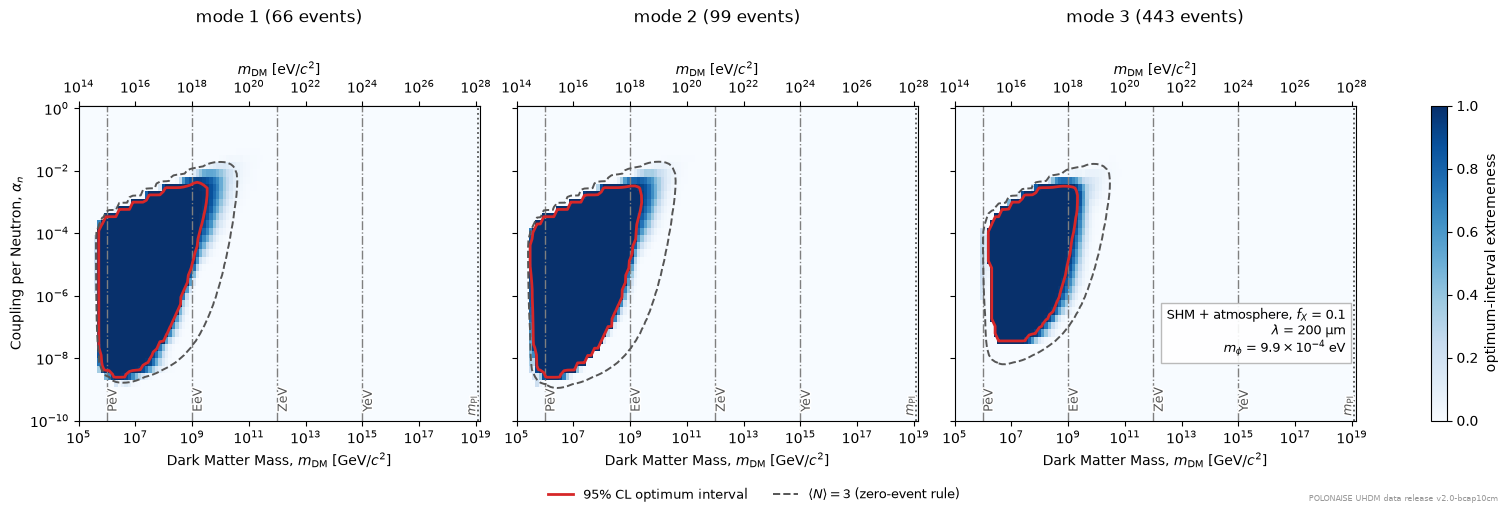

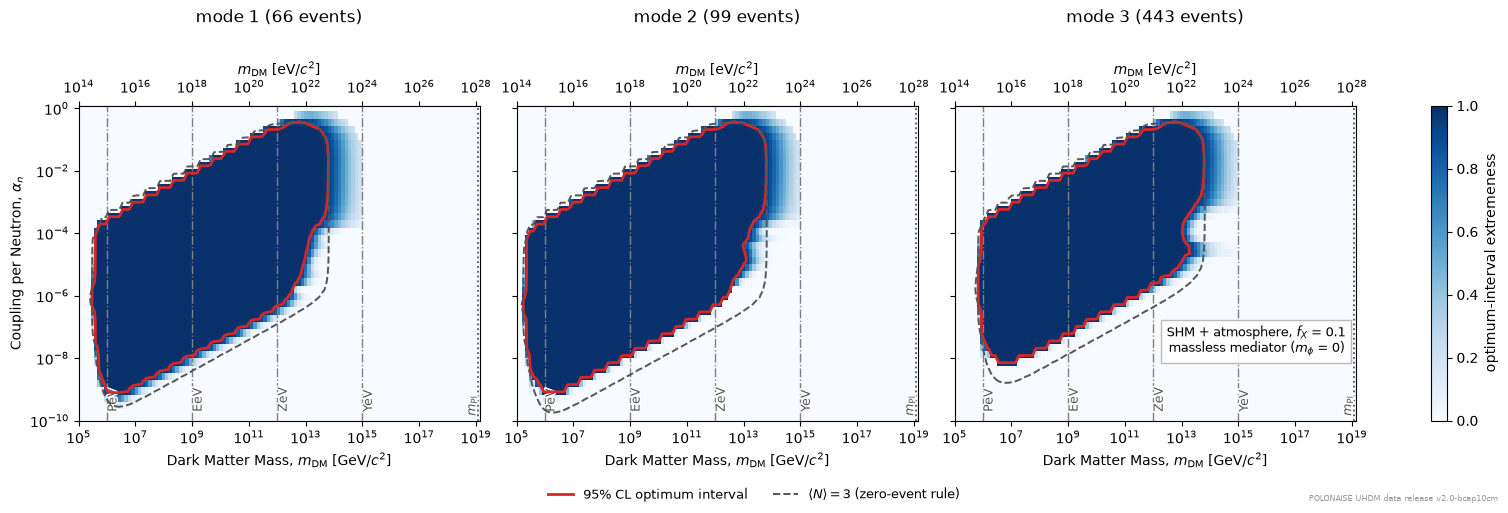

In [4]:
MODES = (1, 2, 3)   # every panel figure below shows all three sensor modes

def excluded_region_panels(tag, fname, info):
    """One panel per mode: extremeness plane, 95% CL and <N> = 3 contours."""
    ms, alphas_n = rel.axes.mass_gev, rel.axes.alpha_n
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True,
                             constrained_layout=True)
    for ax, mode in zip(axes, MODES):
        p = rel.mass_plane("extremeness", mode, tag)
        mu = rel.mass_plane("mu", mode, tag)
        mesh = ax.pcolormesh(ms, alphas_n, p, cmap="Blues", vmin=0, vmax=1,
                             shading="auto")
        ax.contour(ms, alphas_n, p, levels=[CONFIDENCE], colors="#d62728",
                   linewidths=2)
        ax.contour(ms, alphas_n, mu, levels=[3.0], colors="#555555",
                   linewidths=1.4, linestyles="--")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
        mark_mass_milestones(ax, ms.min(), M_PLANCK)
        mark_planck_mass(ax, ms[-1])
        sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                                    lambda x: x / 1e9))
        sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
        ax.set_title(f"mode {mode} ({rel.events(mode).size} events)", pad=28)
    axes[0].set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    fig.colorbar(mesh, ax=axes, label="optimum-interval extremeness")
    # one legend for the whole figure: the two contours mean the same thing
    # in every panel, so proxy lines on the first panel carry the labels
    axes[0].plot([], [], color="#d62728", lw=2,
                 label=f"{CONFIDENCE:.0%} CL optimum interval")
    axes[0].plot([], [], color="#555555", lw=1.4, ls="--",
                 label=r"$\langle N\rangle = 3$ (zero-event rule)")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=2, fontsize=9, frameon=False)
    # info box once, in the last panel's empty high-mass / low-coupling corner
    axes[2].text(0.975, 0.20, info, transform=axes[2].transAxes,
                 ha="right", va="bottom", fontsize=9,
                 bbox=dict(fc="white", ec="0.7", alpha=0.9))
    save_figure(fig, fname)


excluded_region_panels(
    REF_TAG, "01_excluded_region_200um",
    "SHM + atmosphere, $f_X$ = 0.1\n"
    + lamb_label(LAMB_REF) + "\n"
    + mphi_label(LAMB_REF))
excluded_region_panels(
    "massless", "01_excluded_massless",
    "SHM + atmosphere, $f_X$ = 0.1\n"
    + r"massless mediator ($m_\phi$ = 0)")

### All seven ranges

The 95% CL contours for the seven planned ranges, with this mode's candidates
and atmospheric attenuation everywhere. The momentum cap
$\tilde q_\text{max} = K_1(\xi)$, $\xi = R_\text{eff}/\lambda$, organizes the
family:

- **Shared floor at long range.** The longest ranges (mm and above) sit in the
  Coulomb regime and share a common coupling floor; the shorter ranges pay the
  momentum-cap penalty and floor out higher.
- **High-mass endpoints ladder with $\lambda$.** Reach saturates at
  $\sigma_\text{sat} \sim \lambda^2$ while the number density falls as $f_X/m$,
  so each decade of $\lambda$ buys roughly two decades of mass reach; every
  finite-range island closes below the Planck mass.
- **The massless analytic line (black dashed) is the $\lambda\to\infty$ ideal.**
  Its Coulomb reach grows as $\alpha$ without limit, but this release truncates
  the impact-parameter integral at $b_\text{cap} = 10$ cm, so the massless island
  closes too, at $m \approx 5\times10^{13}$ GeV — short of the Planck mass. Once
  their reach exceeds the cap the longest finite ranges collapse onto it: 2 m and
  2 cm share that same endpoint (the 2 m and massless 95% masks agree over 99.8%
  of the grid). The cross section there is the analytic $2\pi\alpha^2/(v^2q^3)$
  times the capped retained fraction, with the atmospheric Coulomb log regulated
  at 2 m.
- **The shortest ranges exclude little or nothing.** As $\xi$ grows the
  saturated rate drops below the 95% exclusion bar; these are honest nulls, not
  plotting gaps. The 2 µm case is omitted from the figures but kept in the scans
  and the data export.

The floor values and high-mass endpoints are read straight off the figure and the
data release; they are not quoted here because they depend on the mode, its
candidate list, and the fiducials above.

    2m: m in [3.0e+05, 5.2e+13] GeV, alpha_n down to 1.5e-09
   2cm: m in [3.0e+05, 5.2e+13] GeV, alpha_n down to 1.5e-09
   2mm: m in [4.0e+05, 6.4e+11] GeV, alpha_n down to 1.5e-09
 200um: m in [5.2e+05, 2.6e+09] GeV, alpha_n down to 2.5e-09
  20um: m in [9.0e+05, 1.1e+07] GeV, alpha_n down to 6.2e-08
  10um: m in [1.2e+06, 2.1e+06] GeV, alpha_n down to 9.0e-07
   2um: no exclusion (max p = 0.20, max mu = 4.82)
massless: m in [3.0e+05, 5.2e+13] GeV, alpha_n down to 8.5e-10


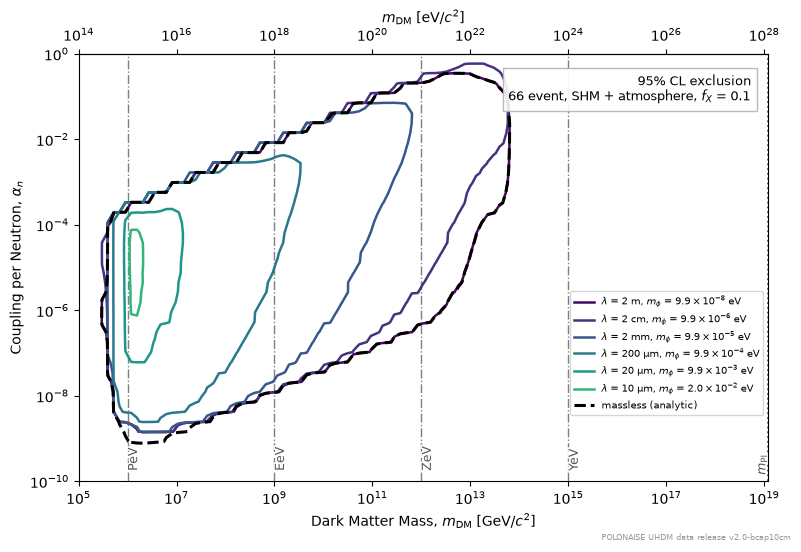

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
CS95 = {}
for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS or tag in HIDE:
        continue
    s = SCANS[tag]
    style = dict(linestyles="--", linewidths=2.2) if lamb is None else \
        dict(linewidths=1.8)
    lab = ("massless (analytic)" if lamb is None
           else range_legend(lamb))
    if (s["extremeness"] >= CONFIDENCE).any():
        CS95[tag] = ax.contour(s["ms"], s["alphas_n"], s["extremeness"],
                               levels=[CONFIDENCE], colors=color, **style)
        ax.plot([], [], color=color, lw=style["linewidths"],
                ls="--" if lamb is None else "-", label=lab)
    else:
        ax.plot([], [], color=color, lw=1.8, label=lab + " (no exclusion)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(REF["ms"].min(), M_PLANCK)
ax.set_ylim(REF["alphas_n"].min(), 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_mass_milestones(ax, REF["ms"].min(), M_PLANCK)
mark_planck_mass(ax, REF["ms"][-1])
sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                            lambda x: x / 1e9))
sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
n_shown = len([t for t, _, _ in LAMBDAS if t not in HIDE])
ax.text(0.975, 0.955,
        f"{CONFIDENCE:.0%} CL exclusion\n"
        f"{EVENTS.size} event, SHM + atmosphere, $f_X$ = 0.1",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="center right", bbox_to_anchor=(1.0, 0.30), fontsize=7)
fig.tight_layout()
save_figure(fig, "01_all_mediator_ranges")

for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    excl = s["extremeness"] >= CONFIDENCE
    if excl.any():
        m_ex = np.broadcast_to(s["ms"], excl.shape)[excl]
        a_ex = np.broadcast_to(s["alphas_n"][:, None], excl.shape)[excl]
        print(f"{tag:>6}: m in [{m_ex.min():.1e}, {m_ex.max():.1e}] GeV, "
              f"alpha_n down to {a_ex.min():.1e}")
    else:
        print(f"{tag:>6}: no exclusion (max p = {s['extremeness'].max():.2f}, "
              f"max mu = {s['counts'].max():.2f})")

### Sensitivity vs mediator range at the best mass

Fixing $m_\text{DM}$ at the mass that gives the **widest exclusion in the
$(\alpha_n, \lambda)$ plane** — chosen to reach the shortest mediator length
(the shared criterion `luhdm.release.best_mass_index`, also used per mode in
notebook 04) — and scanning the mediator
range $\lambda$ (a continuous grid from $0.1\ \mu$m to 2 m) against the coupling
$\alpha_n$ (down to $10^{-10}$), with this mode's detection efficiency folded in. The excluded
band is bounded below by the statistics floor, which deepens with range and
levels off at the Coulomb value once $\lambda \gtrsim$ mm (the momentum cap
stops mattering), and above by the atmospheric ceiling, which is nearly
$\lambda$-independent (atmospheric stopping is set by scattering off air nuclei,
not by the sensor). The band **pinches off** where the rising floor meets the
ceiling as $\lambda$ shrinks: below that range this mass is untestable at any
coupling, which is why the shortest-range channels return nulls in the
mass–coupling figure above.

[`04_mode_comparison.ipynb`](04_mode_comparison.ipynb) repeats this scan for
**all three modes side by side**, and adds a dedicated **1–20 µm zoom** that
resolves exactly where the pinch-off sits.

best mass m_DM = 2.06e+06 GeV


/tmp/ipykernel_554775/3869183322.py:32: RuntimeWarning: divide by zero encountered in divide
  lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))


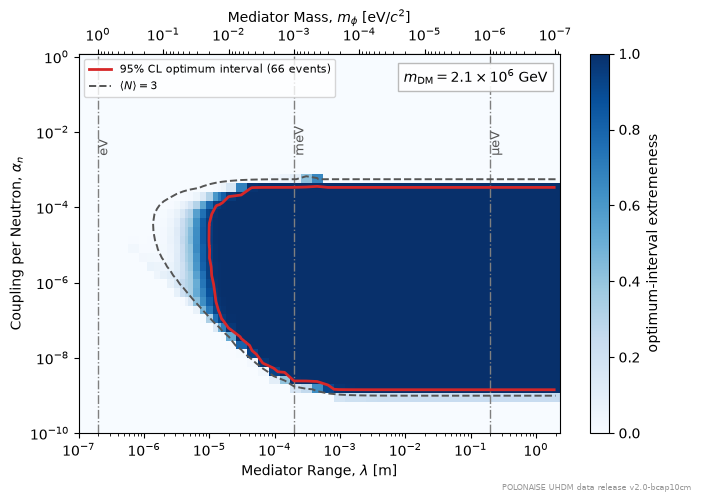

In [6]:
# best mass = widest 95% CL exclusion in the (alpha, lambda) plane, prioritizing
# reach to the shortest mediator length. The criterion now lives in
# luhdm.release.best_mass_index (shared with notebook 04 so the two cannot drift).
M_BEST, IM_BEST = rel.best_mass(MODE_NUMBER)
print(f"best mass m_DM = {M_BEST:.2e} GeV")

# lambda scan at the best mass: the (alpha_n, lambda) extremeness / counts planes.
lambs_l = rel.axes.lambda_finite
alphas_l = rel.axes.alpha_n
p_l = rel.lambda_plane("extremeness", MODE_NUMBER, mass=M_BEST)
mu_l = rel.lambda_plane("mu", MODE_NUMBER, mass=M_BEST)
m_fixed = M_BEST

fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(lambs_l, alphas_l, p_l, cmap="Blues", vmin=0, vmax=1,
                     shading="auto")
fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
CS95_L = ax.contour(lambs_l, alphas_l, p_l, levels=[CONFIDENCE],
                    colors="#d62728", linewidths=2)
ax.contour(lambs_l, alphas_l, mu_l, levels=[3.0], colors="#555555",
           linewidths=1.4, linestyles="--")
ax.plot([], [], color="#d62728", lw=2,
        label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} events)")
ax.plot([], [], color="#555555", lw=1.4, ls="--",
        label=r"$\langle N\rangle = 3$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Mediator Range, $\lambda$ [m]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
secax = ax.secondary_xaxis(
    "top", functions=(lambda x: 1e9 / units.conv_m2pGeV(x),
                      lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))
secax.set_xlabel(r"Mediator Mass, $m_\phi$ [eV/$c^2$]")

# SI-prefix milestones that land inside the plotted mass window
SI_EV = [(1e-24, "yeV"), (1e-21, "zeV"), (1e-18, "aeV"), (1e-15, "feV"),
         (1e-12, "peV"), (1e-9, "neV"), (1e-6, "µeV"), (1e-3, "meV"),
         (1.0, "eV")]
lam_of_ev = lambda m_ev: 1e9 / units.conv_m2pGeV(1.0) / m_ev  # lambda [m]
for m_ev, name in SI_EV:
    lam_mark = lam_of_ev(m_ev)
    if lambs_l.min() < lam_mark < lambs_l.max():
        ax.axvline(lam_mark, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
        ax.text(lam_mark, 0.72, f" {name}", color="#555555", fontsize=9,
                ha="left", va="bottom", rotation=90,
                transform=ax.get_xaxis_transform())
e_b = int(np.floor(np.log10(m_fixed)))
ax.text(0.975, 0.96,
        rf"$m_{{\rm DM}} = {m_fixed / 10**e_b:.1f}\times10^{{{e_b}}}$ GeV",
        transform=ax.transAxes, ha="right", va="top", fontsize=10,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
save_figure(fig, "01_sensitivity_vs_range")

## Machine-readable output

Every surface, contour, and event list on the plots above now lives in the
POLONAISE UHDM **data release** (`release/luhdm_datarelease_v2.h5`), read here
through `luhdm.release`; it supersedes the old per-notebook
`limit_contour_data.npz` export. See
[`06_datarelease.ipynb`](06_datarelease.ipynb) for the schema, the loader API,
and how to pull any slice (including the raw-HDF5 route with no luhdm code).

## Notes

- **Data**: regenerate `data_mode{n}.txt` in notebook 00 (or edit it) and re-run.
  More candidates only move the extremeness surfaces; the machinery is untouched.
- Every surface here is precomputed once by **`scripts/build_release.py`** (the
  per-$\lambda$ cube builder, run on a many-core node) and assembled into the
  HDF5 data release by **`scripts/assemble_release.py`**; this notebook only
  *reads* it through **`luhdm.release`**, so notebook and cluster runs cannot
  drift. The underlying physics lives in **`luhdm/rate.py`** and the fiducials in
  **`luhdm/config.py`** (threshold, exposure, $f_X$, …).
- The $\langle N\rangle \simeq 3$ dashed contour is the zero-candidate rule; the
  solid optimum-interval contour reduces to it only where no candidate falls in
  the kinematic window.